# Librosa feature classification workflow

This notebook is organized around reusable functions. To run the same workflow for a different librosa feature file, change only `FEATURE_CSV` in the configuration cell.

In [283]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model._logistic"
)

In [284]:
BASE_DIR = os.getcwd()
METADATA_CSV = os.path.join(BASE_DIR, "fma_metadata", "tracks.csv")
FEATURE_CSV = os.path.join(BASE_DIR, "features_small_librosa_70.csv")

RANDOM_STATE = 42
TEST_SPLITS = ("test", "validation")
PCA_COMPONENTS = 4

## Reusable data preparation functions

In [285]:
def load_fma_small_tracks(metadata_csv):
    # Load FMA metadata and keep only track id, genre and split for FMA Small.
    tracks = pd.read_csv(metadata_csv, index_col=0, header=[0, 1])
    small_tracks = tracks[tracks[("set", "subset")] == "small"]
    metadata = small_tracks[[("track", "genre_top"), ("set", "split")]].reset_index()
    metadata.columns = ["track_id", "genre_top", "split"]
    return metadata


def load_feature_table(feature_csv):
    # Load a previously computed librosa feature table.
    if not os.path.exists(feature_csv):
        raise FileNotFoundError(
            f"Feature file not found: {feature_csv}. Change FEATURE_CSV to an existing file."
        )
    return pd.read_csv(feature_csv)


def attach_metadata(features_df, tracks_df):
    # Merge audio features with FMA genre and split metadata.
    data = features_df.merge(
        tracks_df[["track_id", "genre_top", "split"]],
        on="track_id",
        how="left",
        validate="one_to_one",
    )
    genre = data.pop("genre_top")
    data.insert(1, "genre", genre)
    return data


def fill_numeric_missing_by_genre(data, genre_col="genre"):
    # Fill numeric missing values with genre means, then global means as fallback.
    data = data.copy()
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    grouped_means = data.groupby(genre_col)[numeric_cols].transform("mean")
    data[numeric_cols] = data[numeric_cols].fillna(grouped_means)
    data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())
    return data


def prepare_librosa_dataset(feature_csv, metadata_csv):
    # Full loading pipeline for any librosa feature table with track_id column.
    tracks = load_fma_small_tracks(metadata_csv)
    features = load_feature_table(feature_csv)
    data = attach_metadata(features, tracks)
    data = fill_numeric_missing_by_genre(data)
    return data, tracks


def split_features(
    data,
    train_split="training",
    test_splits=TEST_SPLITS,
    target_col="genre",
    drop_cols=("track_id", "genre", "split"),
):
    # Return train/test feature matrices and labels using the FMA split column.
    train_mask = data["split"] == train_split
    test_mask = data["split"].isin(test_splits)

    X_train = data.loc[train_mask].drop(columns=list(drop_cols))
    y_train = data.loc[train_mask, target_col]
    X_test = data.loc[test_mask].drop(columns=list(drop_cols))
    y_test = data.loc[test_mask, target_col]

    print(f"Training tracks: {X_train.shape[0]}")
    print(f"Test (+validation) tracks: {X_test.shape[0]}")
    print(f"Feature count: {X_train.shape[1]}")

    return X_train, X_test, y_train, y_test

## Reusable transformation and plotting functions

In [286]:
def scale_train_test(X_train, X_test):
    # Fit a StandardScaler on train data and transform train/test matrices.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


def apply_pca(X_train, X_test, n_components=PCA_COMPONENTS, random_state=RANDOM_STATE):
    # Fit PCA on train data and transform train/test matrices.
    pca = PCA(n_components=n_components, random_state=random_state)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    return X_train_pca, X_test_pca, pca


def plot_pca_explained_variance(pca, threshold=0.70):
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    components = np.arange(1, len(cumulative) + 1)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=components, y=cumulative, color="skyblue")
    plt.axhline(y=threshold, color="red", linestyle="--", label=f"{threshold:.0%} variance")
    for i, value in enumerate(cumulative):
        plt.text(i, value + 0.02, f"{value:.2f}", ha="center", va="bottom")
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.legend()
    plt.show()


def plot_pca_scatter(X_train_pca, y_train):
    if X_train_pca.shape[1] < 2:
        raise ValueError("At least two PCA components are required for a scatter plot.")

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette="Set2")
    plt.title("PC1 vs PC2")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Genre")
    plt.show()


def draw_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

## Reusable modeling functions

In [287]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test, print_report=False):
    # Fit a classifier and return metrics, predictions and the fitted estimator.
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred_train = fitted_model.predict(X_train)
    y_pred_test = fitted_model.predict(X_test)

    result = {
        "name": name,
        "model": fitted_model,
        "y_pred_train": y_pred_train,
        "y_pred_test": y_pred_test,
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "macro_f1": f1_score(y_test, y_pred_test, average="macro"),
    }

    print(f"{name} Train Accuracy: {result['train_accuracy']:.4f}")
    print(f"{name} Test Accuracy: {result['test_accuracy']:.4f}")
    print(f"{name} Macro F1: {result['macro_f1']:.4f}")

    if print_report:
        print()
        print(f"Classification Report - {name}:")
        print(classification_report(y_test, y_pred_test))

    return result


def run_model_suite(model_specs, X_train, X_test, y_train, y_test, print_report=False):
    # Evaluate several models and return both a summary table and detailed results.
    results = {}
    for name, model in model_specs:
        print("-" * 60)
        results[name] = evaluate_classifier(
            name,
            model,
            X_train,
            X_test,
            y_train,
            y_test,
            print_report=print_report,
        )

    summary = pd.DataFrame(
        [
            {
                "model": name,
                "train_accuracy": result["train_accuracy"],
                "test_accuracy": result["test_accuracy"],
                "macro_f1": result["macro_f1"],
            }
            for name, result in results.items()
        ]
    ).sort_values("test_accuracy", ascending=False)

    return summary, results


def get_lightgbm_classifier():
    # Create LightGBM only when the package is available in the environment.
    try:
        from lightgbm import LGBMClassifier
    except ImportError:
        print("LightGBM is not installed, skipping LGBMClassifier.")
        return None

    return LGBMClassifier(
        n_estimators=50,
        learning_rate=0.04,
        max_depth=5,
        random_state=RANDOM_STATE,
        verbose=-1,
    )


def pca_model_specs():
    return [
        ("SVM linear + PCA", SVC(kernel="linear", C=1, random_state=RANDOM_STATE)),
        ("SVM RBF", SVC(kernel="rbf", C=0.1, gamma=0.01, random_state=RANDOM_STATE)),
        (
            "Random Forest + PCA",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=7,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
            ),
        ),
    ]


def no_pca_model_specs():
    specs = [
        (
            "Random Forest",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=7,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
            ),
        ),
        ("SVM linear", SVC(kernel="linear", C=1, random_state=RANDOM_STATE)),
        ("SVM RBF", SVC(kernel="rbf", C=0.1, gamma=0.01, random_state=RANDOM_STATE)),
        (
            "Logistic Regression",
            LogisticRegression(C=10, penalty="l2", solver="lbfgs", random_state=RANDOM_STATE),
        ),
        (
            "Gradient Boosting",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.01,
                max_depth=4,
                subsample=0.8,
                random_state=RANDOM_STATE,
            ),
        ),
    ]

    lgbm = get_lightgbm_classifier()
    if lgbm is not None:
        specs.insert(3, ("LightGBM", lgbm))

    return specs


def draw_result_confusion_matrix(results, model_name, y_test, title=None):
    result = results[model_name]
    draw_confusion_matrix(
        y_test,
        result["y_pred_test"],
        result["model"].classes_,
        title or f"Confusion Matrix - {model_name}",
    )

## Load and prepare data

In [288]:
df, df_tracks = prepare_librosa_dataset(FEATURE_CSV, METADATA_CSV)

display(df.head(3))
print(df.shape)
display(df["split"].value_counts())
display(df["genre"].value_counts())

,track_id,genre,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,...,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01,split
0,2,Hip-Hop,0.747006,0.465571,0.376991,0.346401,0.276217,0.234040,0.272904,0.419900,...,7.230115,7.195039,6.366723,0.085953,0.053469,3056.587891,997.470154,0.164406,0.093938,training
1,5,Hip-Hop,0.408774,0.578310,0.398189,0.341066,0.322690,0.329029,0.373279,0.398300,...,6.629267,8.085360,8.035872,0.088805,0.053615,2430.188965,878.139465,0.100544,0.067248,training
2,10,Pop,0.283685,0.649419,0.330624,0.347292,0.231403,0.323438,0.700743,0.338985,...,6.350440,5.508020,5.445374,0.114076,0.031983,2358.129150,382.231567,0.148947,0.028327,training


(8000, 73)


split
training      6400
validation     800
test           800
Name: count, dtype: int64

genre
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

In [289]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
display(missing_summary.head(10))
display(df.describe())

track_id               0
genre                  0
chroma_stft_mean_01    0
chroma_stft_mean_02    0
chroma_stft_mean_03    0
chroma_stft_mean_04    0
chroma_stft_mean_05    0
chroma_stft_mean_06    0
chroma_stft_mean_07    0
chroma_stft_mean_08    0
dtype: int64

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,84126.770125,0.384153,0.358588,0.389807,0.362426,0.390536,0.365014,0.363271,0.393923,0.372966,...,7.123442,7.184168,7.304115,7.425555,0.109186,0.038522,1900.345000,618.298764,0.084189,0.041452
std,43297.426287,0.152839,0.139345,0.149271,0.141920,0.151528,0.147427,0.142069,0.149294,0.145997,...,2.057759,2.097927,2.226888,2.380265,0.059035,0.020522,710.045044,312.447756,0.044135,0.025614
min,2.000000,0.000086,0.000028,0.000160,0.013705,0.000107,0.002560,0.006492,0.003290,0.001849,...,1.986344,1.603659,2.280345,2.260303,0.000005,0.000000,194.182846,19.656221,0.000000,0.000000
25%,49063.500000,0.273948,0.258644,0.284567,0.259755,0.282736,0.259966,0.263401,0.289450,0.268044,...,5.715921,5.777391,5.791659,5.803681,0.064954,0.023269,1392.002197,383.831131,0.053732,0.023435
50%,89281.000000,0.375412,0.349119,0.383240,0.353619,0.385797,0.357011,0.356580,0.390202,0.364646,...,6.833184,6.863219,6.973696,7.017993,0.102611,0.034711,1884.867248,582.305450,0.076833,0.035815
75%,122545.000000,0.482452,0.446623,0.481659,0.451587,0.488489,0.458809,0.453405,0.490336,0.466023,...,8.102801,8.193904,8.340853,8.542696,0.145489,0.049832,2368.226623,812.604615,0.105589,0.053379
max,155066.000000,1.000000,0.992950,0.996802,0.989316,0.975264,0.999956,0.974532,1.000000,0.997444,...,22.927616,20.595741,21.905958,28.510353,0.534026,0.169386,6765.746582,2237.504639,0.626993,0.215885


## Train/test split

In [290]:
X_train, X_test, y_train, y_test = split_features(df)
display(X_test.head(3))

Training tracks: 6400
Test (+validation) tracks: 1600
Feature count: 70


,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,chroma_stft_mean_10,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
5,0.235886,0.232199,0.220317,0.345158,0.254844,0.252132,0.488326,0.447359,0.427648,0.505443,...,5.480647,8.221957,7.426013,7.875948,0.293337,0.039733,1711.434326,543.107666,0.088242,0.039756
6,0.307800,0.294771,0.357591,0.478392,0.309814,0.464462,0.392004,0.452348,0.321431,0.300152,...,6.520124,6.738981,7.086237,7.002125,0.168167,0.018307,1877.022949,361.361237,0.100594,0.025330
23,0.301953,0.446219,0.862435,0.554715,0.327869,0.361980,0.466859,0.462144,0.294620,0.408278,...,4.211380,4.203982,4.149111,4.068082,0.225355,0.031492,1960.402344,566.062500,0.063766,0.023469


## PCA workflow

PCA train shape: (6400, 4)


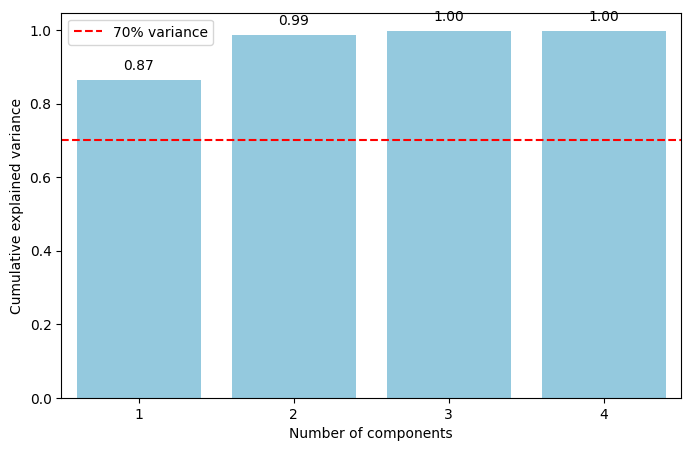

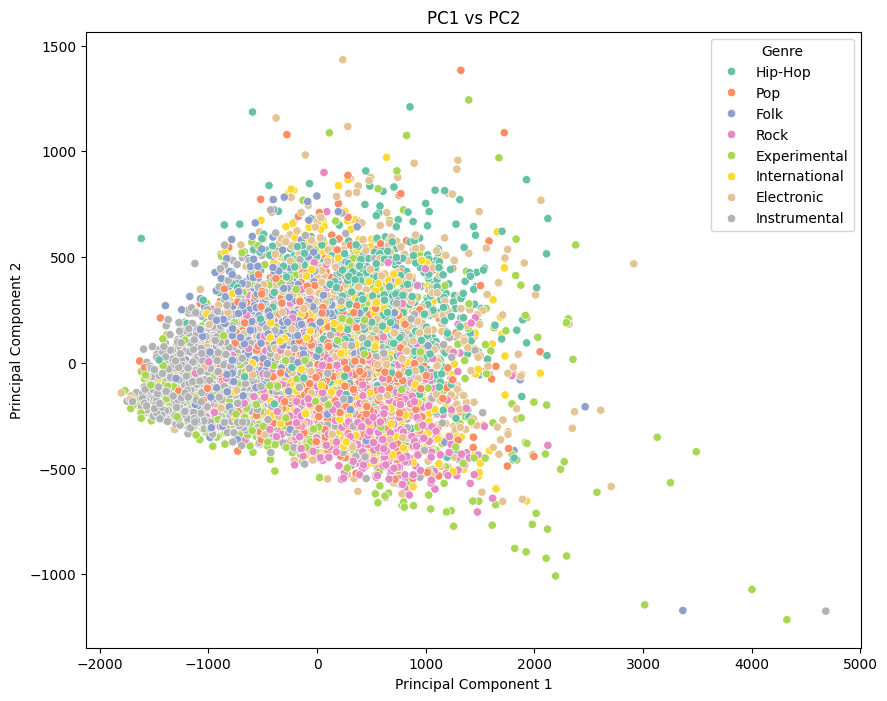

In [291]:
X_train_pca_raw, X_test_pca_raw, pca = apply_pca(X_train, X_test, n_components=PCA_COMPONENTS)
print(f"PCA train shape: {X_train_pca_raw.shape}")

plot_pca_explained_variance(pca, threshold=0.70)
plot_pca_scatter(X_train_pca_raw, y_train)

In [292]:
X_train_pca, X_test_pca, pca_scaler = scale_train_test(X_train_pca_raw, X_test_pca_raw)

pca_summary, pca_results = run_model_suite(
    pca_model_specs(),
    X_train_pca,
    X_test_pca,
    y_train,
    y_test,
)

display(pca_summary)

------------------------------------------------------------
SVM linear + PCA Train Accuracy: 0.3420
SVM linear + PCA Test Accuracy: 0.3387
SVM linear + PCA Macro F1: 0.3138
------------------------------------------------------------
SVM RBF Train Accuracy: 0.3391
SVM RBF Test Accuracy: 0.3181
SVM RBF Macro F1: 0.2866
------------------------------------------------------------
Random Forest + PCA Train Accuracy: 0.4519
Random Forest + PCA Test Accuracy: 0.3294
Random Forest + PCA Macro F1: 0.3120


,model,train_accuracy,test_accuracy,macro_f1
0,SVM linear + PCA,0.342031,0.338750,0.313787
2,Random Forest + PCA,0.451875,0.329375,0.312027
1,SVM RBF,0.339062,0.318125,0.286646


## Confusion matrices for PCA models

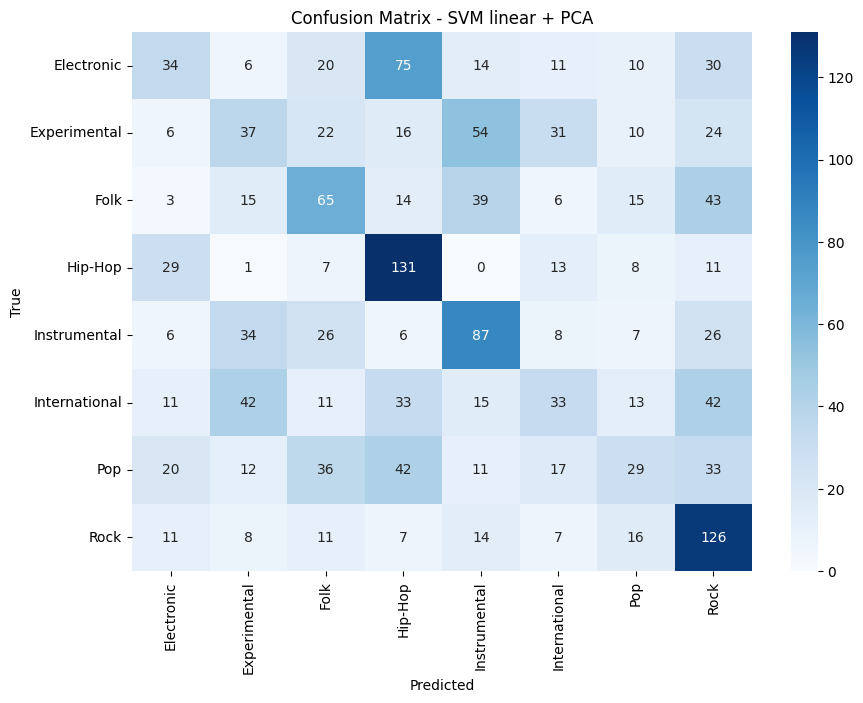

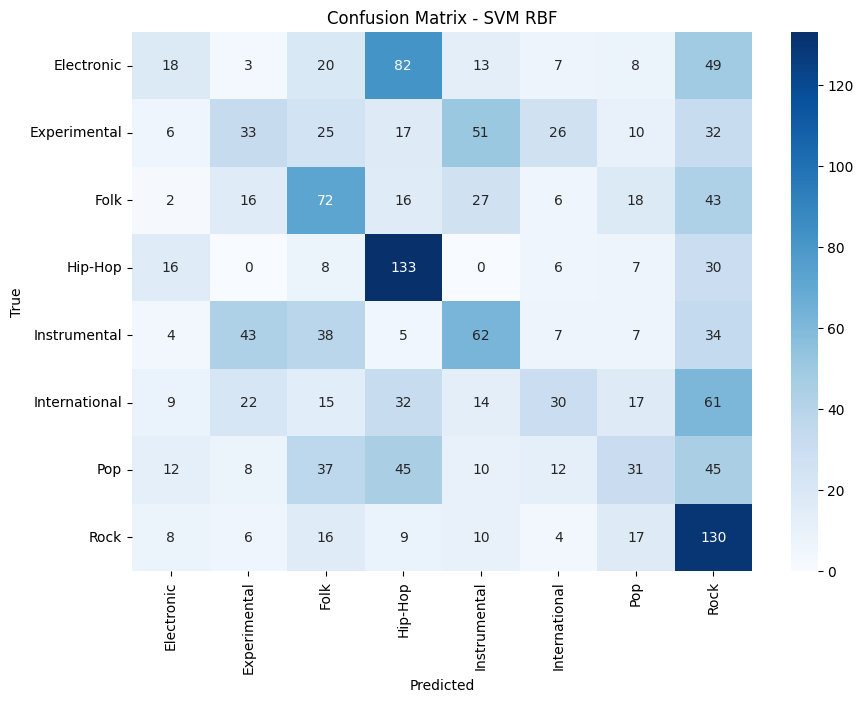

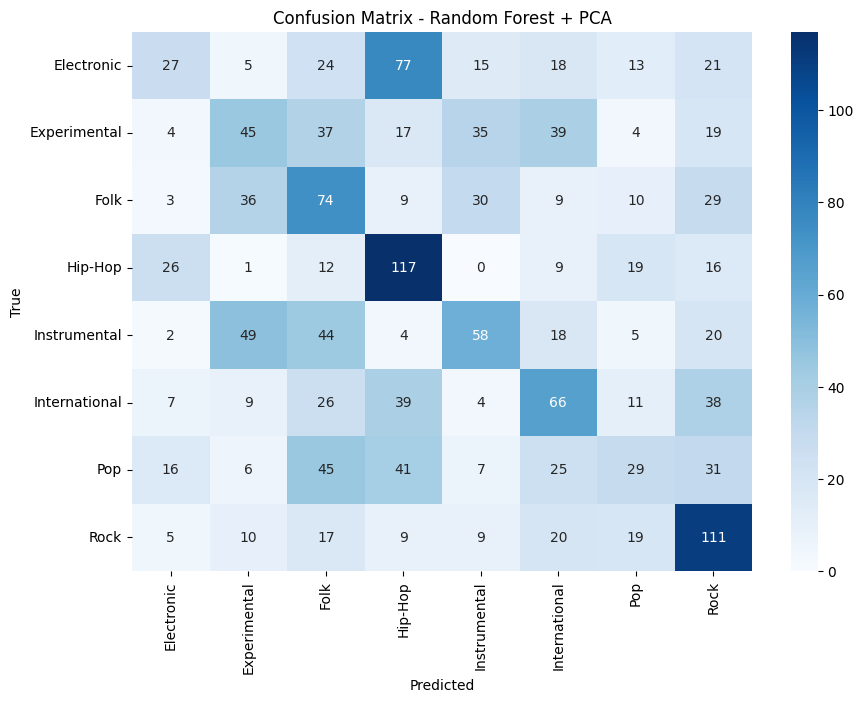

In [293]:
for model_name in pca_results:
    draw_result_confusion_matrix(
        pca_results,
        model_name,
        y_test,
        f"Confusion Matrix - {model_name}",
    )

## Modeling without PCA

In [294]:
X_train_scaled, X_test_scaled, scaler = scale_train_test(X_train, X_test)
print(f"No-PCA train shape: {X_train_scaled.shape}")

no_pca_summary, no_pca_results = run_model_suite(
    no_pca_model_specs(),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
)

display(no_pca_summary)

No-PCA train shape: (6400, 70)
------------------------------------------------------------
Random Forest Train Accuracy: 0.5978
Random Forest Test Accuracy: 0.4381
Random Forest Macro F1: 0.4213
------------------------------------------------------------
SVM linear Train Accuracy: 0.5358
SVM linear Test Accuracy: 0.3981
SVM linear Macro F1: 0.3961
------------------------------------------------------------
SVM RBF Train Accuracy: 0.5061
SVM RBF Test Accuracy: 0.4456
SVM RBF Macro F1: 0.4347
------------------------------------------------------------
LightGBM Train Accuracy: 0.7377
LightGBM Test Accuracy: 0.4437
LightGBM Macro F1: 0.4379
------------------------------------------------------------
Logistic Regression Train Accuracy: 0.5059
Logistic Regression Test Accuracy: 0.3937
Logistic Regression Macro F1: 0.3863
------------------------------------------------------------
Gradient Boosting Train Accuracy: 0.6003
Gradient Boosting Test Accuracy: 0.4238
Gradient Boosting Macro F1

,model,train_accuracy,test_accuracy,macro_f1
2,SVM RBF,0.506094,0.445625,0.434653
3,LightGBM,0.737656,0.443750,0.437861
0,Random Forest,0.597812,0.438125,0.421305
5,Gradient Boosting,0.600313,0.423750,0.415771
1,SVM linear,0.535781,0.398125,0.396095
4,Logistic Regression,0.505938,0.393750,0.386331


## Confusion matrices for selected models

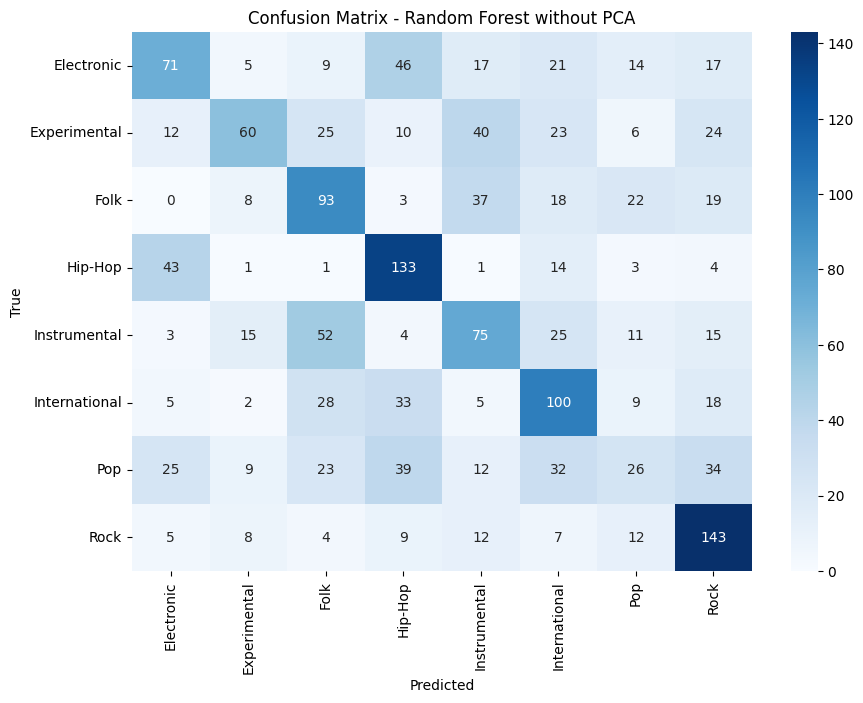

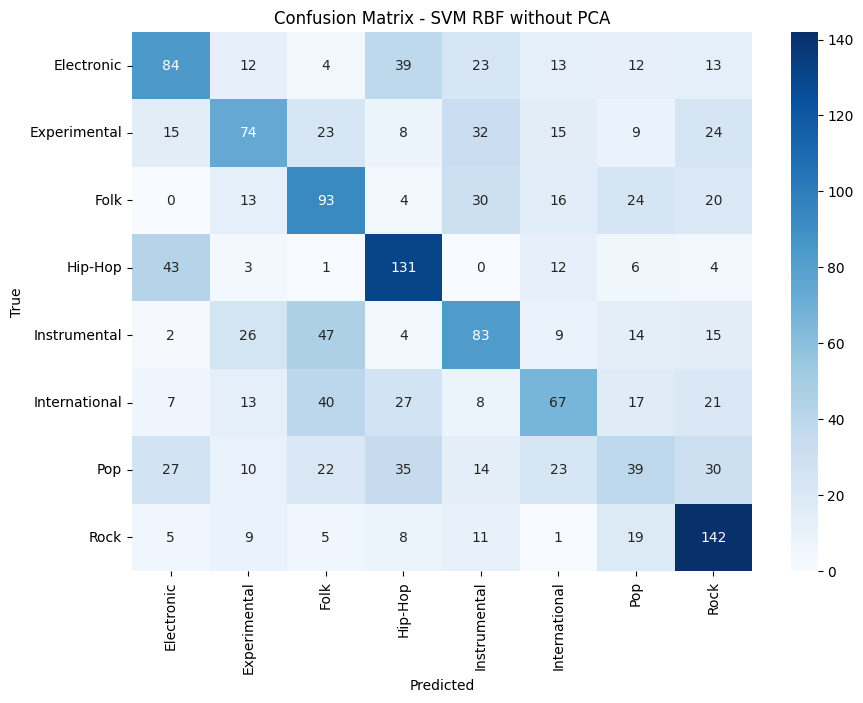

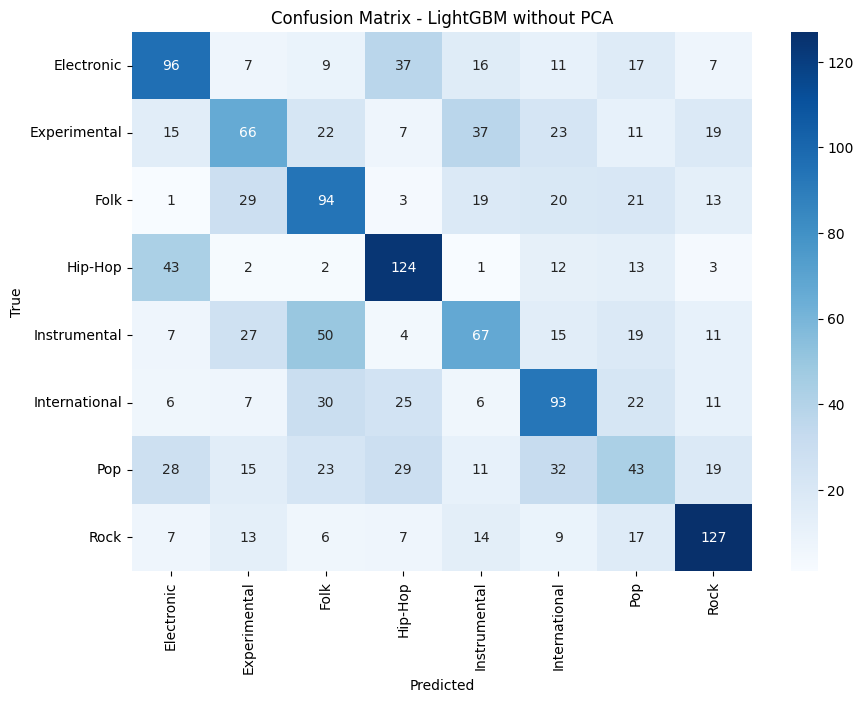

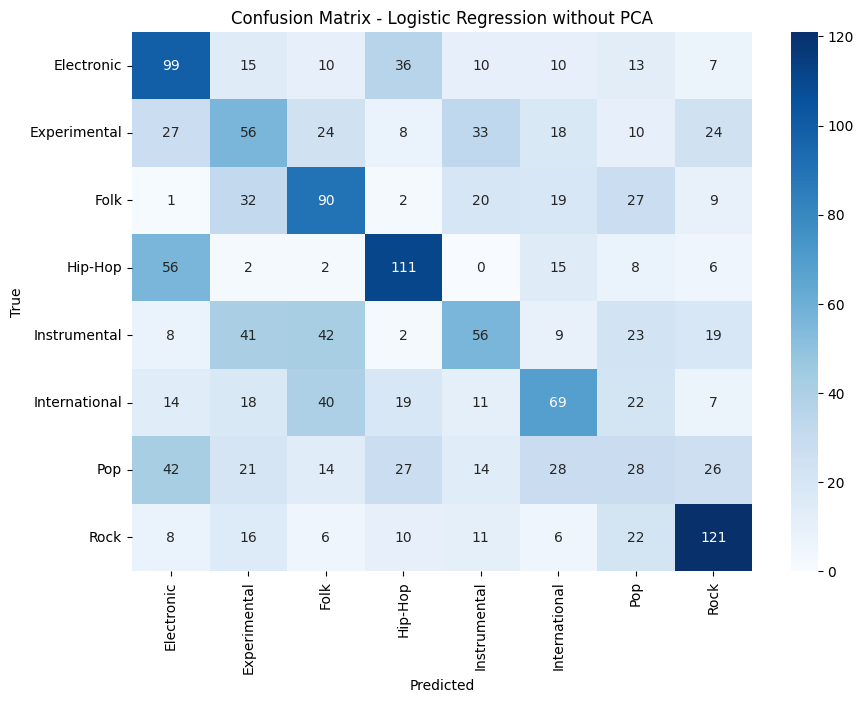

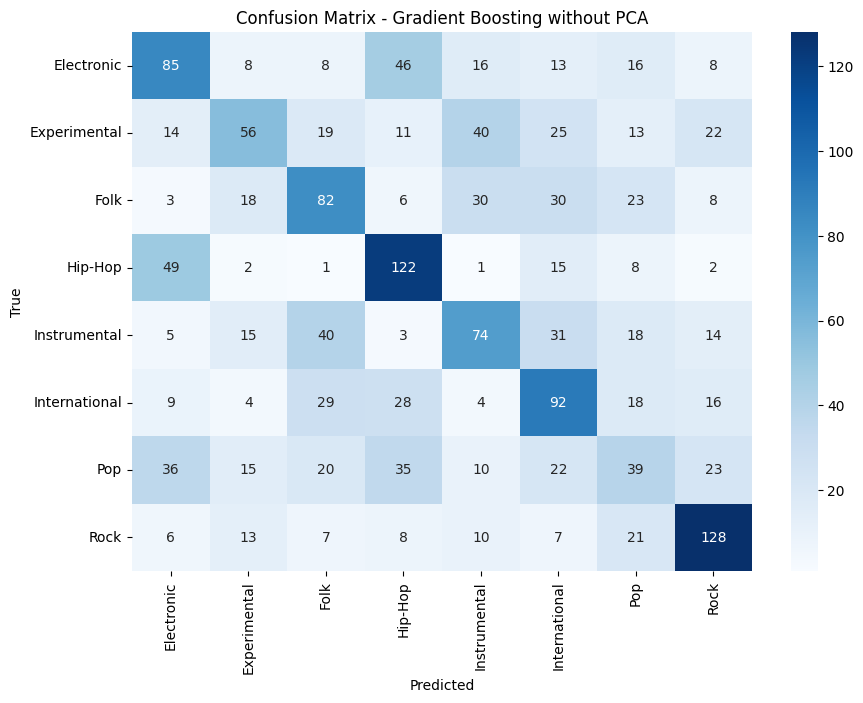

In [295]:
draw_result_confusion_matrix(no_pca_results, "Random Forest", y_test, "Confusion Matrix - Random Forest without PCA")
draw_result_confusion_matrix(no_pca_results, "SVM RBF", y_test, "Confusion Matrix - SVM RBF without PCA")

if "LightGBM" in no_pca_results:
    draw_result_confusion_matrix(no_pca_results, "LightGBM", y_test, "Confusion Matrix - LightGBM without PCA")

draw_result_confusion_matrix(no_pca_results, "Logistic Regression", y_test, "Confusion Matrix - Logistic Regression without PCA")
draw_result_confusion_matrix(no_pca_results, "Gradient Boosting", y_test, "Confusion Matrix - Gradient Boosting without PCA")

## Combined result table

In [296]:
combined_summary = pd.concat(
    [
        pca_summary.assign(representation="PCA top 4"),
        no_pca_summary.assign(representation="No PCA"),
    ],
    ignore_index=True,
).sort_values("test_accuracy", ascending=False)

display(combined_summary)

,model,train_accuracy,test_accuracy,macro_f1,representation
3,SVM RBF,0.506094,0.445625,0.434653,No PCA
4,LightGBM,0.737656,0.443750,0.437861,No PCA
5,Random Forest,0.597812,0.438125,0.421305,No PCA
6,Gradient Boosting,0.600313,0.423750,0.415771,No PCA
7,SVM linear,0.535781,0.398125,0.396095,No PCA
8,Logistic Regression,0.505938,0.393750,0.386331,No PCA
0,SVM linear + PCA,0.342031,0.338750,0.313787,PCA top 4
1,Random Forest + PCA,0.451875,0.329375,0.312027,PCA top 4
2,SVM RBF,0.339062,0.318125,0.286646,PCA top 4
